In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from mgdraw_output_reader_NOVO_vAMB import DetectionDataStorage
from helper_functions_2 import find_HU_group_info
from voxel_GT_composition import find_voxel_GT_composition

### Data loading for one file

In [2]:
data_path = r"D:\Study_spectroscopy\HNC_simulations\sim_3_5\scintillator_interactions"

file = DetectionDataStorage(folder_path = data_path, primaries_per_spawn = 5e6, max_files = 100)

file.load_data()
file.filter_hits(write_hits_to_file = True)

Reading 108 scintillator_interactions.txt-files
Max files reached: 100/100, stopping data collection
Total time used on data collection: 103.1 s

-----------ICODE FILTERING-----------
Raw hit filtering complete. Time used: 52.69 s
Total number of lines: 3449526
Number of lines kept: 860185 (24.9%)
Number of lines rejected: 2589341 (75.1%)

-----------HIT MERGING-----------
Merging complete. Time used: 22.42 s
Overlaps found: 132318
Total number of hit histories > 10/200 keV: 454733
Number of gamma hit histories > 10 keV: 285307
Number of neutron hit histories > 200 keV: 168745
Number of combo hit histories > 200 keV: 681
D:/Study_spectroscopy/HNC_simulations/sim_3_5/gamma_hits.txt successfully created
D:/Study_spectroscopy/HNC_simulations/sim_3_5/neutron_hits.txt successfully created
D:/Study_spectroscopy/HNC_simulations/sim_3_5/all_hits.txt successfully created


In [3]:
file.filter_hits(write_hits_to_file = True)


-----------ICODE FILTERING-----------
Raw hit filtering complete. Time used: 17.7 s
Total number of lines: 1187616
Number of lines kept: 287774 (24.2%)
Number of lines rejected: 899842 (75.8%)

-----------HIT MERGING-----------
Merging complete. Time used: 7.33 s
Overlaps found: 42670
Total number of hit histories > 10/200 keV: 164816
Number of gamma hit histories > 10 keV: 100856
Number of neutron hit histories > 200 keV: 63867
Number of combo hit histories > 200 keV: 93
D:/Study_spectroscopy/HNC_simulations/sim_0_0/gamma_hits.txt successfully created
D:/Study_spectroscopy/HNC_simulations/sim_0_0/neutron_hits.txt successfully created
D:/Study_spectroscopy/HNC_simulations/sim_0_0/all_hits.txt successfully created


In [4]:
gamma_hits_path = r"d:\Study_spectroscopy\HNC_simulations\sim_0_0\gamma_hits.txt"
'''
with open(gamma_hits_path, "r") as f:
    lines = f.readlines()
    num_hits = len(lines)
    num_elements = len(lines[0]) 
    hit_array = []
    for line in lines:
        elements = np.array(line.split()).astype(float)
        hit_array.append(elements)

hit_array = np.array(hit_array)'''

def get_gamma_hits(gamma_hits_path):
    
    with open(gamma_hits_path, "r") as f:
        lines = f.readlines()
        hit_array = []
        
        for line in lines:
            elements = np.array(line.split()).astype(float)
            hit_array.append(elements)

    hit_array = np.array(hit_array)

    return hit_array

hit_array = get_gamma_hits(gamma_hits_path)

In [ ]:
energy_dep = hit_array[:,7]


### Plotting (for testing)

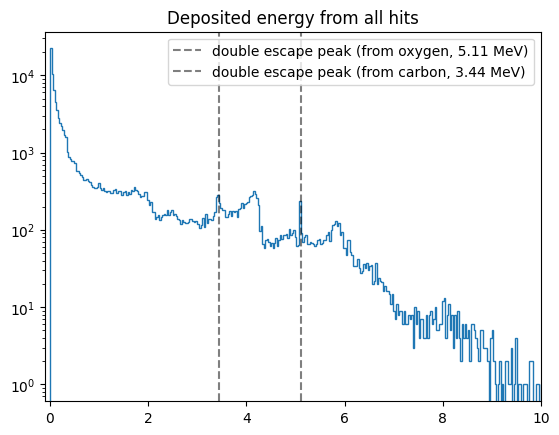

In [53]:
plt.figure()
plt.title("Deposited energy from all hits")

plt.hist(energy_dep, bins = 500, histtype = "step")
plt.axvline(x = 5.11, color = "black", linestyle = "--", alpha = 0.5, label = "double escape peak (from oxygen, 5.11 MeV)")
plt.axvline(x = 3.44, color = "black", linestyle = "--", alpha = 0.5, label = "double escape peak (from carbon, 3.44 MeV)")

plt.yscale("log")
plt.xlim(-0.1, 10)
plt.legend()

plt.show()

In [42]:
icodes = hit_array[:,1]
ncases = hit_array[:,0]
print(set(icodes))
print(len(ncases))
print(len(set(ncases)))


{np.float64(219.0), np.float64(221.0)}
100856
87716


In [48]:
# merge for ncase

energy_dep_merged = []
ncase_checked = []

# NB: fix to start at zero
for i in range(len(hit_array)):
    
    current_hit = hit_array[i]
    current_ncase = current_hit[0]
    
    # only for speed up
    if len(ncase_checked) < 100: 
        if current_ncase not in ncase_checked:
            energy_dep_merged.append(current_hit[7])
            ncase_checked.append(current_ncase)
        
        if current_ncase in ncase_checked:
            energy_dep_merged[-1] += current_hit[7]
    else:
        if current_ncase not in ncase_checked[-10:]:
            energy_dep_merged.append(current_hit[7])
            ncase_checked.append(current_ncase)
        
        if current_ncase in ncase_checked[-10:0]:
            energy_dep_merged[-1] += current_hit[7]

print(len(energy_dep_merged))






87716


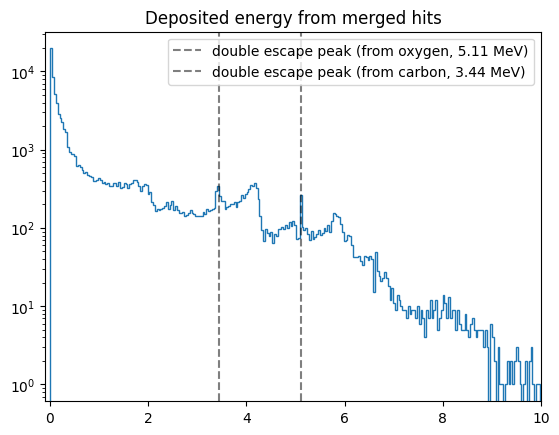

In [52]:
plt.figure()
plt.title("Deposited energy from merged hits")

plt.hist(energy_dep_merged, bins = 500, histtype = "step")
plt.axvline(x = 5.11, color = "black", linestyle = "--", alpha = 0.5, label = "double escape peak (from oxygen, 5.11 MeV)")
plt.axvline(x = 3.44, color = "black", linestyle = "--", alpha = 0.5, label = "double escape peak (from carbon, 3.44 MeV)")

plt.yscale("log")
plt.xlim(-0.1, 10)
plt.legend()
plt.show()

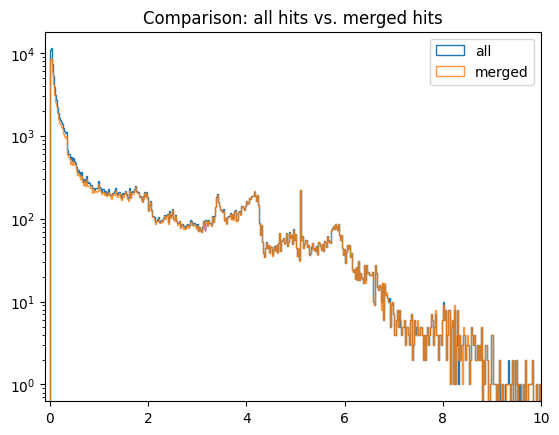

In [63]:
plt.figure()
plt.title("Comparison: all hits vs. merged hits")

bins = np.linspace(0, 10, 500)


plt.hist(energy_dep, bins = bins, histtype = "step", label = "all")
plt.hist(energy_dep_merged, bins = bins, histtype = "step", label = "merged", alpha = 0.8)
#plt.axvline(x = 5.11, color = "black", linestyle = "--", alpha = 0.5, label = "double escape peak (from oxygen, 5.11 MeV)")
#plt.axvline(x = 3.44, color = "black", linestyle = "--", alpha = 0.5, label = "double escape peak (from carbon, 3.44 MeV)")

plt.yscale("log")
plt.xlim(-0.1, 10)
plt.legend()
plt.show()

### Hitfile creation for multiple files

In [2]:
folder_path = r"D:\Study_spectroscopy\HNC_simulations"
folders = os.listdir(folder_path)

for folder in folders[:3]: 
    data_path = folder_path + "/" + folder + "/" + "scintillator_interactions"
    
    file = DetectionDataStorage(folder_path = data_path, primaries_per_spawn = 5e6, max_files = 100)
    file.load_data()
    file.filter_hits(write_hits_to_file = True)

Reading 108 scintillator_interactions.txt-files
Max files reached: 100/100, stopping data collection
Total time used on data collection: 30.72 s

-----------ICODE FILTERING-----------
Raw hit filtering complete. Time used: 19.01 s
Total number of lines: 1187616
Number of lines kept: 287774 (24.2%)
Number of lines rejected: 899842 (75.8%)

-----------HIT MERGING-----------
Merging complete. Time used: 8.07 s
Overlaps found: 42670
Total number of hit histories > 10/200 keV: 164816
Number of gamma hit histories > 10 keV: 100856
Number of neutron hit histories > 200 keV: 63867
Number of combo hit histories > 200 keV: 93
D:/Study_spectroscopy/HNC_simulations/sim_0_0/gamma_hits.txt successfully created
D:/Study_spectroscopy/HNC_simulations/sim_0_0/neutron_hits.txt successfully created
D:/Study_spectroscopy/HNC_simulations/sim_0_0/all_hits.txt successfully created
Reading 109 scintillator_interactions.txt-files
Max files reached: 100/100, stopping data collection
Total time used on data colle

### Compare spectroscopy runs

In [34]:
gamma_hits_run_1 = r"d:\Study_spectroscopy\HNC_simulations\sim_0_0\gamma_hits.txt"
gamma_hits_run_2 = r"d:\Study_spectroscopy\HNC_simulations\sim_0_5\gamma_hits.txt"

hit_array_1 = get_gamma_hits(gamma_hits_run_1)
hit_array_2 = get_gamma_hits(gamma_hits_run_2)

energy_dep_1 = hit_array_1[:,7]
energy_dep_2 = hit_array_2[:,7]

regions_1 = hit_array_1[:,-1]
regions_2 = hit_array_2[:,-1]

### Find region info

In [35]:
output_file_path = r"d:\Study_spectroscopy\HNC_simulations\sim_0_0\sim_0_0_aa001.out"

# Find the HU group for each mreg
voxel_start_line = 124540 #79721 # In the section === Regions: materials and fields ===, choose the line above the first region
voxel_end_line = 132486 #84675 # Choose the line after the last voxel, obs: not the empty line but the one before. 

# Search up the composition and density of each HU group. 
HU_start_line = 123558#78766 # In the section === Material compositions: ===, choose the line before the first HU-group. 
HU_end_line = 124152#79343 #choose the line after the last element of the last HU group

GT_1 = find_voxel_GT_composition(output_file_path, regions_1, voxel_start_line, voxel_end_line, HU_start_line, HU_end_line)
GT_2 = find_voxel_GT_composition(output_file_path, regions_2, voxel_start_line, voxel_end_line, HU_start_line, HU_end_line)

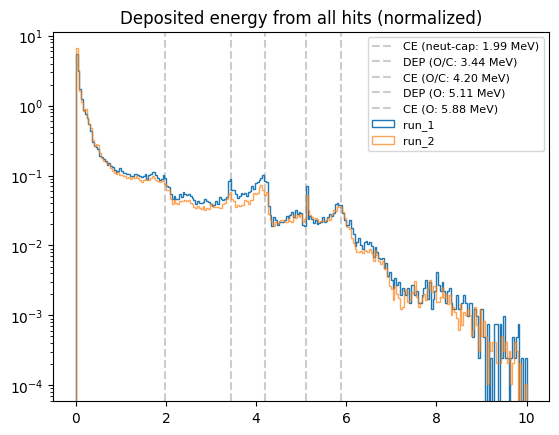

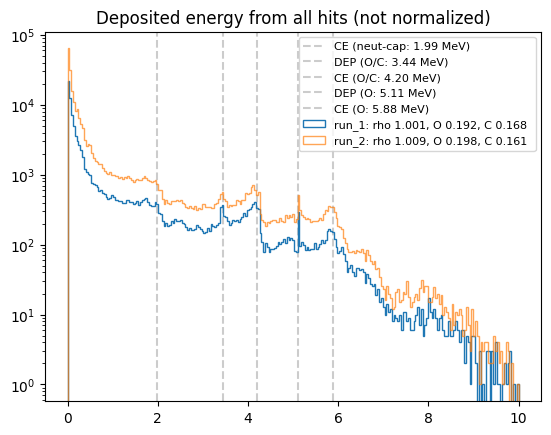

In [36]:
plt.figure()
plt.title("Deposited energy from all hits (normalized)")

bins = np.linspace(0, 10, 250)

plt.axvline(x = 1.99, color = "black", linestyle = "--", alpha = 0.2, label = "CE (neut-cap: 1.99 MeV)")
plt.axvline(x = 3.44, color = "black", linestyle = "--", alpha = 0.2, label = "DEP (O/C: 3.44 MeV)")
plt.axvline(x = 4.20, color = "black", linestyle = "--", alpha = 0.2, label = "CE (O/C: 4.20 MeV)")
plt.axvline(x = 5.11, color = "black", linestyle = "--", alpha = 0.2, label = "DEP (O: 5.11 MeV)")
plt.axvline(x = 5.88, color = "black", linestyle = "--", alpha = 0.2, label = "CE (O: 5.88 MeV)")


plt.hist(energy_dep_1, bins = bins, density = True, histtype = "step", label = "run_1")
plt.hist(energy_dep_2, bins = bins, density = True, histtype = "step", label = "run_2", alpha = 0.7)

plt.yscale("log")
#plt.xlim(-0.1, 10)
plt.legend(fontsize = 8)

plt.show()

plt.figure()
plt.title("Deposited energy from all hits (not normalized)")

bins = np.linspace(0, 10, 250)

plt.axvline(x = 1.99, color = "black", linestyle = "--", alpha = 0.2, label = "CE (neut-cap: 1.99 MeV)")
plt.axvline(x = 3.44, color = "black", linestyle = "--", alpha = 0.2, label = "DEP (O/C: 3.44 MeV)")
plt.axvline(x = 4.20, color = "black", linestyle = "--", alpha = 0.2, label = "CE (O/C: 4.20 MeV)")
plt.axvline(x = 5.11, color = "black", linestyle = "--", alpha = 0.2, label = "DEP (O: 5.11 MeV)")
plt.axvline(x = 5.88, color = "black", linestyle = "--", alpha = 0.2, label = "CE (O: 5.88 MeV)")


plt.hist(energy_dep_1, bins = bins, density = False, histtype = "step", label = f"run_1: rho {np.round(GT_1["density"], 3)}, O {np.round(GT_1["oxygen"], 3)}, C {np.round(GT_1["carbon"], 3)} ")
plt.hist(energy_dep_2, bins = bins, density = False, histtype = "step", label = f"run_2: rho {np.round(GT_2["density"], 3)}, O {np.round(GT_2["oxygen"], 3)}, C {np.round(GT_2["carbon"], 3)} " , alpha = 0.7)

plt.yscale("log")
#plt.xlim(-0.1, 10)
plt.legend(fontsize = 8)

plt.show()